# Setting a Ground Truth

In order to determine which imputation method performs best, we apply a Missing Completely At Random (MCAR) mechanism to the cleaned DataFrame and compare the imputed values with the original observed values using evaluation metrics.

In [42]:
import pandas as pd
from taxipred.utils.constants import TAXI_CSV_PATH

df = pd.read_csv(TAXI_CSV_PATH)
df.info()

# the original DF where we have 5% null values per column,

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [43]:
df_clean = df.dropna().copy()
df_clean.info()

# this will be our ground truth and we will applying 5% MCAR for each column just like we have observed in our original DF.

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Time_of_Day            562 non-null    object 
 2   Day_of_Week            562 non-null    object 
 3   Passenger_Count        562 non-null    float64
 4   Traffic_Conditions     562 non-null    object 
 5   Weather                562 non-null    object 
 6   Base_Fare              562 non-null    float64
 7   Per_Km_Rate            562 non-null    float64
 8   Per_Minute_Rate        562 non-null    float64
 9   Trip_Duration_Minutes  562 non-null    float64
 10  Trip_Price             562 non-null    float64
dtypes: float64(7), object(4)
memory usage: 52.7+ KB


In [44]:
import numpy as np

# getting rid of the non-numeric columns

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean_num = df_clean[numeric_cols].copy()
df_clean_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


In [45]:
# applying MCAR at 5% mechanism

mask_matrix = pd.DataFrame(
    np.random.rand(*df_clean_num.shape) < 0.05,
    index=df_clean_num.index,
    columns=df_clean_num.columns
)

df_masked_num = df_clean_num.mask(mask_matrix)

df_masked_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       536 non-null    float64
 1   Passenger_Count        534 non-null    float64
 2   Base_Fare              537 non-null    float64
 3   Per_Km_Rate            537 non-null    float64
 4   Per_Minute_Rate        527 non-null    float64
 5   Trip_Duration_Minutes  537 non-null    float64
 6   Trip_Price             543 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


# Imputation

I will be applying different imputation methods on the "Ground Truth" dataset and compare evaluation performances to decide which one fits better to fill the null values on the original data.

## Mean Imputation
- This method involves replacing missing values with the mean of the relevant variable. It's a simple approach but it doesn't account for the relationships between variables.

In [46]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy="mean")
df_mean = pd.DataFrame(
    mean_imputer.fit_transform(df_masked_num),
    columns=df_masked_num.columns,
    index=df_masked_num.index
)

df_mean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


## Linear Imputation

- Pros: captures trends, preserves relationships
- Cons: assumes a pattern (linear) may be complex

In [47]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

linear_imputer = IterativeImputer(
    estimator=LinearRegression(),
    max_iter=1,               # key: one pass (linear regression baseline)
    random_state=42,
    sample_posterior=False
)

df_linear = pd.DataFrame(
    linear_imputer.fit_transform(df_masked_num),
    columns=df_masked_num.columns,
    index=df_masked_num.index
)

df_linear.info()


<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


/home/apollonspc/taxi-prediction-fullstack-omer-aytug/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## MICE Imputation
- MICE (Multiple Imputation by Chained Equations) style chained equations (iterative regression imputation) to preserve relationships between variables.

In [48]:
mice_imputer = IterativeImputer(
    estimator=LinearRegression(),
    random_state=42,
    max_iter=20,
    sample_posterior=False
)

df_mice = pd.DataFrame(
    mice_imputer.fit_transform(df_masked_num),
    columns=df_masked_num.columns,
    index=df_masked_num.index
)


df_mice.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


# Evaluation
- RMSE/MAE only on masked cells

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Only evaluate at positions we intentionally masked
y_true   = df_clean_num.values[mask_matrix.values]
y_mean   = df_mean.values[mask_matrix.values]
y_linear = df_linear.values[mask_matrix.values]
y_mice   = df_mice.values[mask_matrix.values]

def rmse(y_t, y_p):
    return np.sqrt(mean_squared_error(y_t, y_p))

def mae(y_t, y_p):
    return mean_absolute_error(y_t, y_p)

results = pd.DataFrame({
    "RMSE": [rmse(y_true, y_mean), rmse(y_true, y_linear), rmse(y_true, y_mice)],
    "MAE":  [mae(y_true, y_mean),  mae(y_true, y_linear),  mae(y_true, y_mice)]
}, index=["Mean", "LinearRegression", "MICE"])

display(results.sort_values("RMSE"))



,RMSE,MAE
MICE,10.658096,4.861948
LinearRegression,11.075433,5.141146
Mean,17.785608,8.791137


- Structure check (varience comparison)

In [50]:
var_compare = pd.DataFrame({
    "True (df_clean_num)": df_clean_num.var(),
    "Mean Imputed": df_mean.var(),
    "Linear Imputed": df_linear.var(),
    "MICE": df_mice.var()
})

display(var_compare)


,True (df_clean_num),Mean Imputed,Linear Imputed,MICE
Trip_Distance_km,447.456825,425.462745,442.089511,442.489618
Passenger_Count,1.229693,1.163412,1.165309,1.165242
Base_Fare,0.758784,0.725488,0.725672,0.725692
Per_Km_Rate,0.185202,0.176839,0.182646,0.185929
Per_Minute_Rate,0.013187,0.012464,0.012577,0.012584
Trip_Duration_Minutes,1032.236406,973.849674,981.577342,986.945825
Trip_Price,1932.370937,1909.738894,1946.585186,1949.296147


### Plot Evaluation

- Analyzing the performance of our imputation models by comparing imputed valued with the actual values for some of the columns

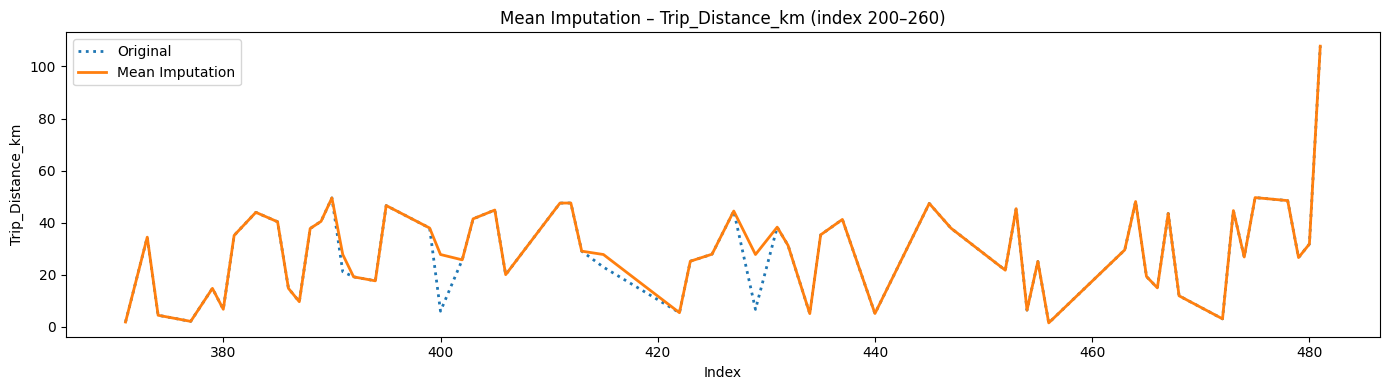

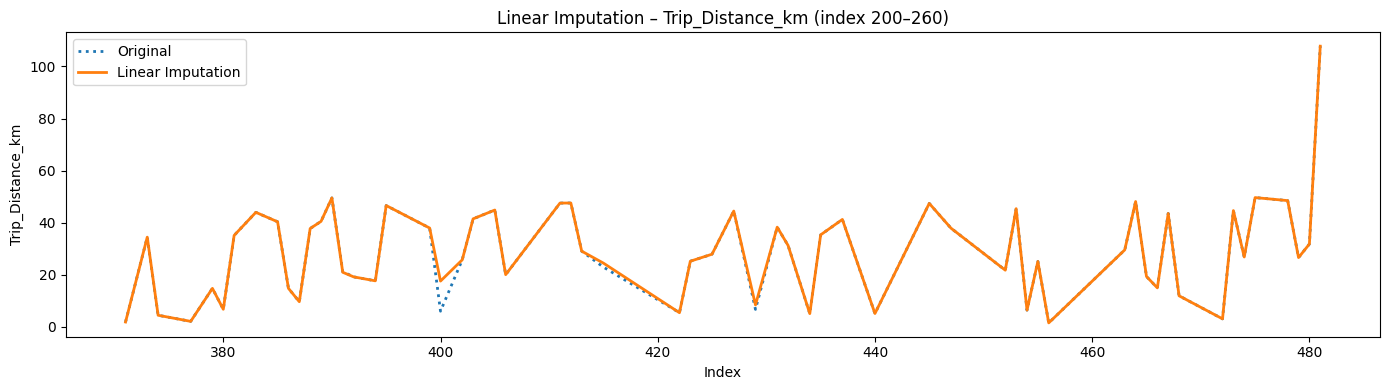

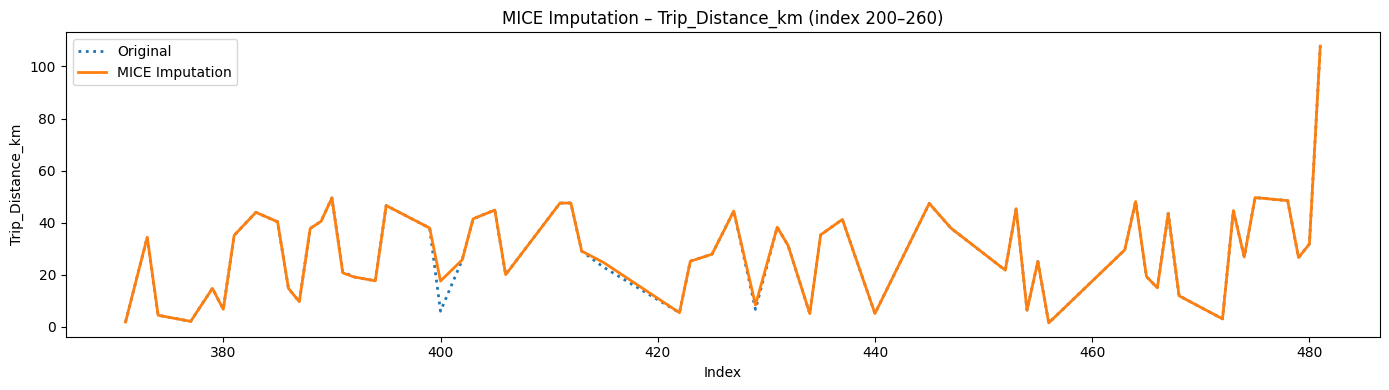

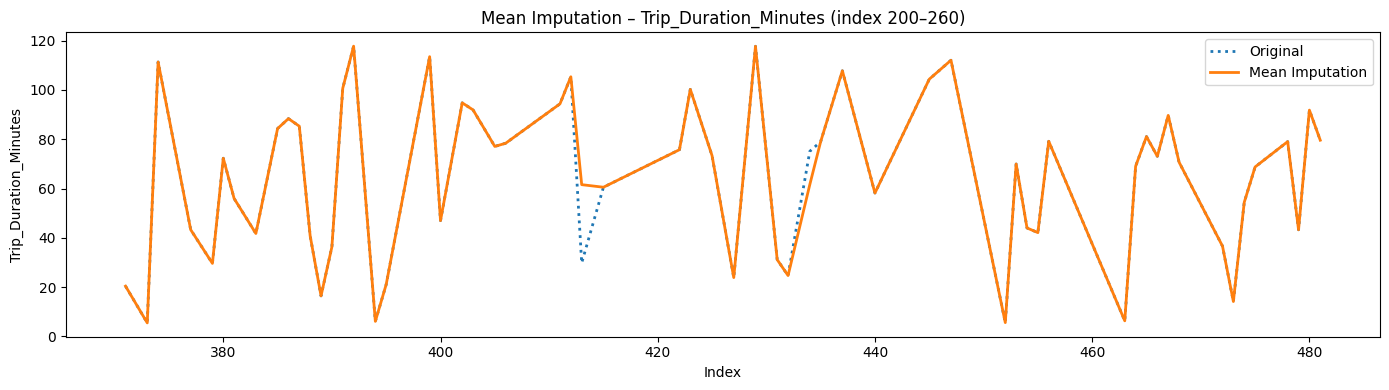

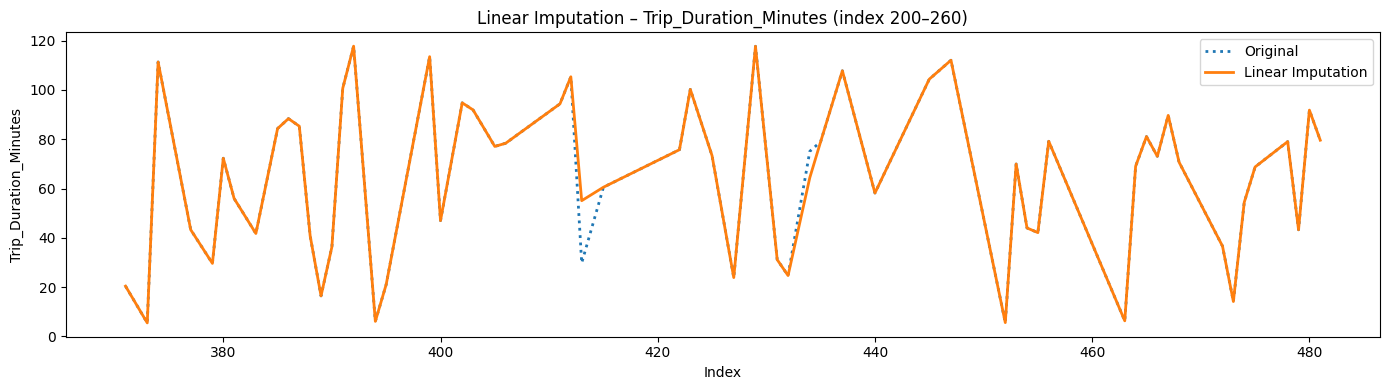

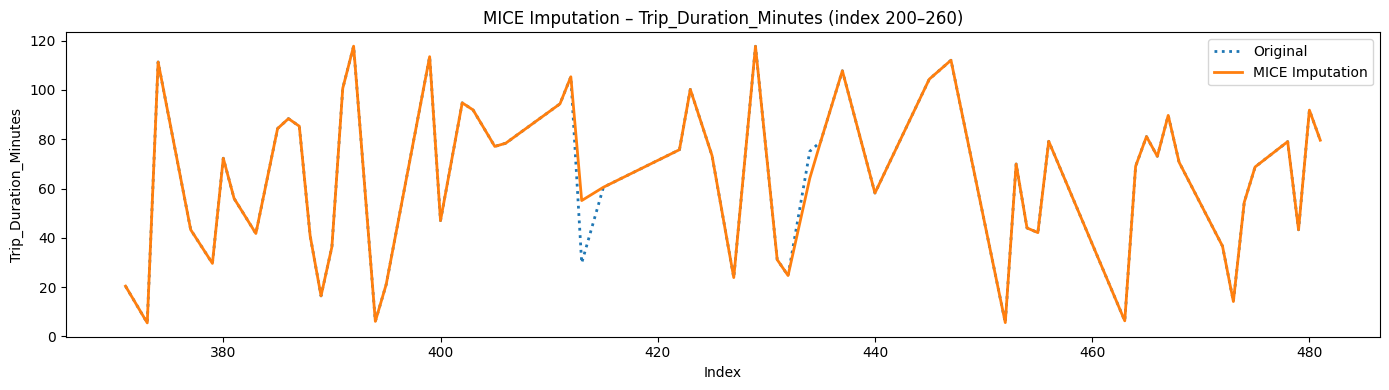

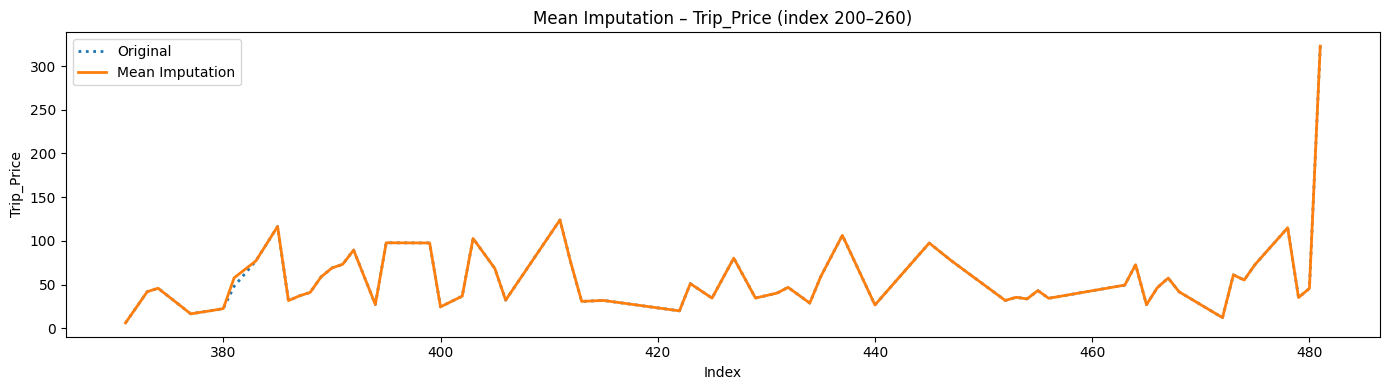

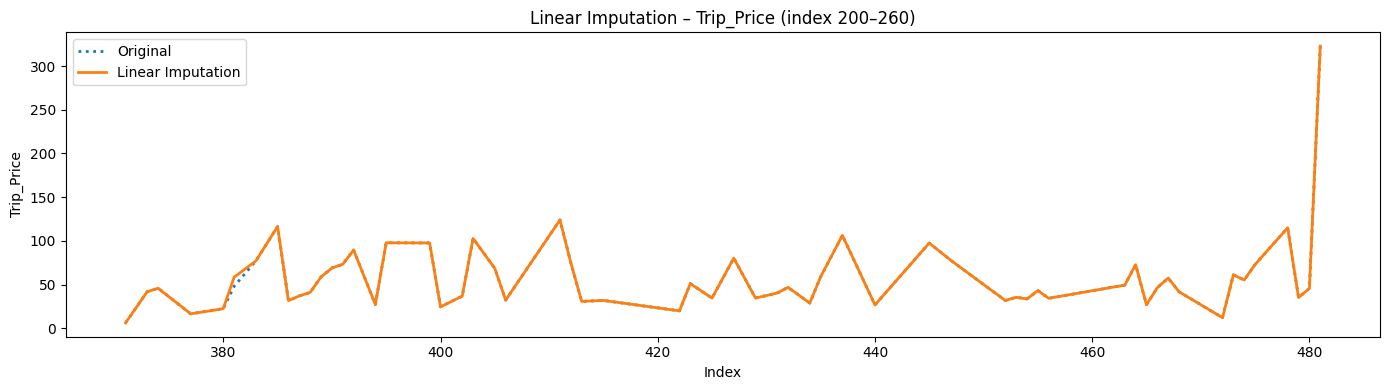

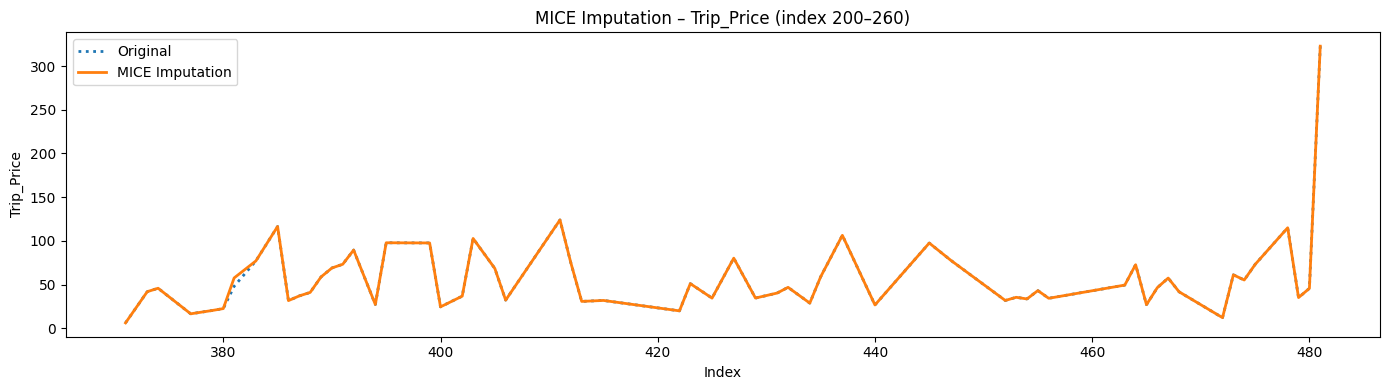

In [51]:
import matplotlib.pyplot as plt

cols_to_check = [
    "Trip_Distance_km",
    "Trip_Duration_Minutes",
    "Trip_Price"
]

start, end = 200, 260   # zoom window

methods = {
    "Mean Imputation": df_mean,
    "Linear Imputation": df_linear,
    "MICE Imputation": df_mice
}

for col in cols_to_check:
    for method_name, df_imp in methods.items():
        plt.figure(figsize=(14, 4))

        # Original (ground truth)
        plt.plot(
            df_clean[col].iloc[start:end],
            label="Original",
            linestyle="dotted",
            linewidth=2
        )

        # Imputed version
        plt.plot(
            df_imp[col].iloc[start:end],
            label=method_name,
            linewidth=2
        )

        plt.title(f"{method_name} – {col} (index {start}–{end})")
        plt.xlabel("Index")
        plt.ylabel(col)
        plt.legend()
        plt.tight_layout()
        plt.show()


- Analyzing our imputation models based on their distributation performance

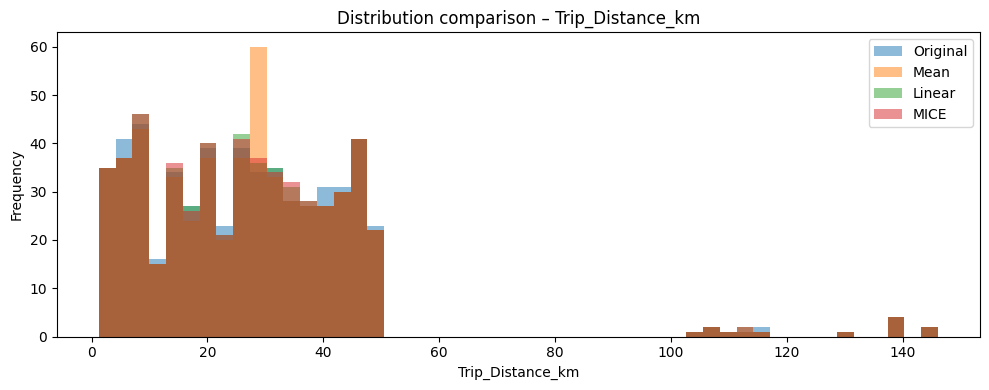

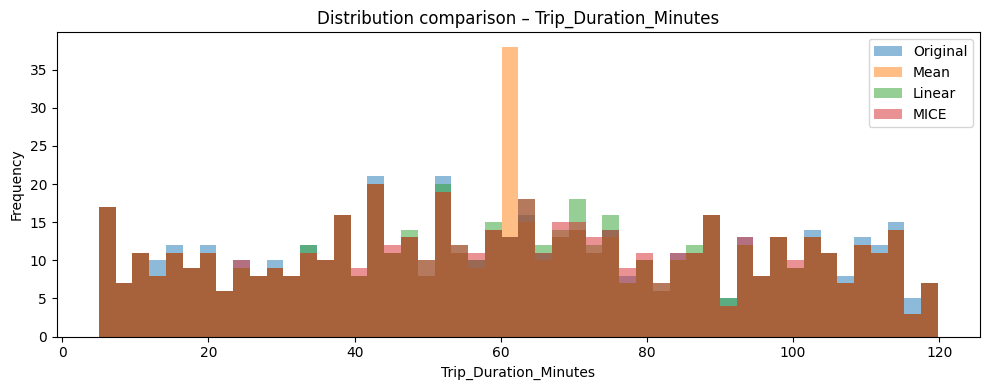

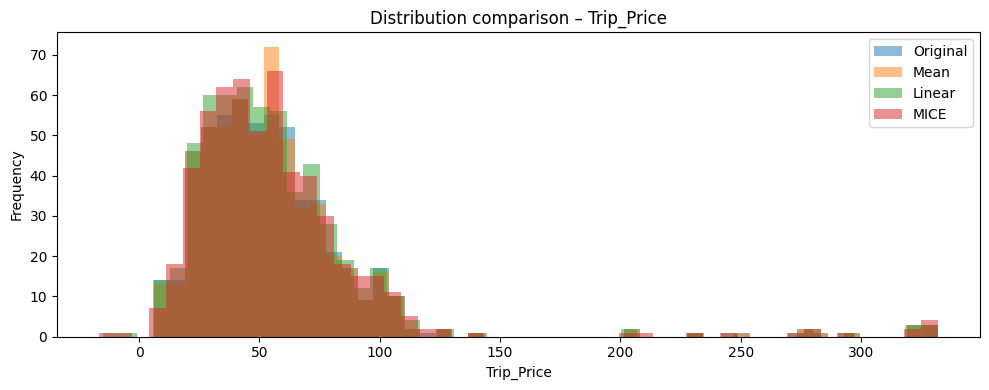

In [52]:
for col in cols_to_check:
    plt.figure(figsize=(10, 4))

    plt.hist(df_clean_num[col], bins=50, alpha=0.5, label="Original")
    plt.hist(df_mean[col], bins=50, alpha=0.5, label="Mean")
    plt.hist(df_linear[col], bins=50, alpha=0.5, label="Linear")
    plt.hist(df_mice[col], bins=50, alpha=0.5, label="MICE")

    plt.title(f"Distribution comparison – {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()
